In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sb

# General utils
from tqdm import tqdm
from os import path
import pickle as pkl

from measurements import get_prev_or_next_frame
from sklearn import preprocessing, model_selection, feature_selection, metrics, inspection, pipeline, ensemble

from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted
import pyvista as pv

%load_ext autoreload
%autoreload 2

In [62]:
# Load data
dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/03-31-2025 feature filtered datasets/cell_cycle_aligned/With relative features'
# dataset_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/'
model_dir = '/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/RF_aligned_delays'

base_str = 'divisions'
suffix = '_feature_filtered.pkl'

basals = pd.read_pickle('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/basals.pkl')
divisions = pd.read_pickle('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/divisions.pkl')
# Mean shape:

# Load the raw coeffs
dirnames = {'R1':'/Users/xies/OneDrive - Stanford/Skin/Mesa et al/W-R1/',
            'R2':'/Users/xies/OneDrive - Stanford/Skin/Mesa et al/W-R2/'}
regions = {name:pd.read_csv(path.join(dirname,'Mastodon/single_timepoints.csv'),
                            index_col=[0,1],header=[0,1]).reset_index()
           for name,dirname in dirnames.items()}

cyto_coef_cols = [f for f,_ in regions['R1'].columns if 'cyto_shcoeffs' in f and 'surface' not in f]
nuc_coef_cols = [f for f,_ in regions['R1'].columns if 'nuc_shcoeffs' in f and 'surface' not in f]

coefs_raw = []
for name,region in regions.items():
    _cyto = region[cyto_coef_cols].copy()
    _cyto['Frame'] = region.reset_index()['Frame']
    _cyto['TrackID'] = name + '_' + region.reset_index()['TrackID'].astype(str)

    _nuc = region[nuc_coef_cols].copy()
    _nuc['Frame'] = region.reset_index()['Frame']
    _nuc['TrackID'] = name + '_' + region.reset_index()['TrackID'].astype(str)
    
    coefs_raw.append(pd.merge(_cyto,_nuc, how='outer',left_on = ['Frame','TrackID'],right_on=['Frame','TrackID']))
    # coefs_raw.append(pd.merge(_cyto,_nuc,left_index=True,right_index=True))

coefs_raw = pd.concat(coefs_raw).set_index(['Frame','TrackID'])
# .set_index(['Frame','TrackID'],drop=True)

mean_shape = coefs_raw.mean().droplevel(level=1)

/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_73516/1680397347.py:33: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  coefs_raw.append(pd.merge(_cyto,_nuc, how='outer',left_on = ['Frame','TrackID'],right_on=['Frame','TrackID']))
/var/folders/zp/5k1kvm9j0t19cvq8h628kr8h0000gn/T/ipykernel_73516/1680397347.py:33: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  coefs_raw.append(pd.merge(_cyto,_nuc, how='outer',left_on = ['Frame','TrackID'],right_on=['Frame','TrackID']))


,nuc_shcoeffs_L0M0C,nuc_shcoeffs_L1M0C,nuc_shcoeffs_L1M1C,nuc_shcoeffs_L2M0C,nuc_shcoeffs_L2M1C,nuc_shcoeffs_L2M2C,nuc_shcoeffs_L3M0C,nuc_shcoeffs_L3M1C,nuc_shcoeffs_L3M2C,nuc_shcoeffs_L3M3C,...,cyto_shcoeffs_L3M3S,cyto_shcoeffs_L4M1S,cyto_shcoeffs_L4M2S,cyto_shcoeffs_L4M3S,cyto_shcoeffs_L4M4S,cyto_shcoeffs_L5M1S,cyto_shcoeffs_L5M2S,cyto_shcoeffs_L5M3S,cyto_shcoeffs_L5M4S,cyto_shcoeffs_L5M5S
PC0,0.594337,0.007321,0.000227,0.034163,0.021189,0.021183,-0.007338,0.003696,0.003885,-0.003117,...,0.010656,0.003714,0.001580,0.001876,0.000738,0.002686,0.000810,0.005378,-0.001564,0.002117
PC1,-0.000606,-0.006795,-0.017080,0.171204,0.478855,0.095973,-0.014392,-0.013604,0.010344,0.003035,...,-0.006303,-0.082557,0.005322,-0.021099,-0.000910,0.010823,-0.008124,-0.001994,0.002161,0.001903
PC2,0.031559,0.012321,-0.005629,-0.081999,0.170667,0.126473,-0.004110,-0.002931,0.004068,0.001596,...,0.006819,0.255356,-0.008313,0.068445,0.008052,-0.048529,0.013383,0.005922,-0.000814,-0.000102
PC3,-0.018639,-0.044117,0.000150,0.329925,-0.069676,-0.212281,0.014547,-0.005316,-0.005084,0.000801,...,0.000691,0.106724,-0.008414,0.023551,0.014373,-0.019886,0.011328,0.003485,-0.000588,-0.001426
PC4,-0.067268,-0.022886,0.010176,0.070995,-0.125709,0.462516,-0.007272,0.008058,0.017780,0.004289,...,-0.005607,0.001508,-0.009942,-0.000438,-0.002835,-0.000345,-0.005044,-0.004334,0.000007,-0.003605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC67,0.001577,-0.010596,-0.010021,-0.010841,-0.003001,-0.002035,0.035370,-0.037640,0.105840,0.017814,...,0.002882,-0.004068,0.000794,-0.002699,0.006612,-0.000319,0.031182,-0.023791,-0.085970,-0.008599
PC68,-0.000765,-0.018884,0.021147,-0.004752,0.000982,-0.002896,0.036171,0.081038,0.090115,0.046470,...,0.008412,-0.001171,-0.008576,0.003778,0.002062,0.000466,-0.062292,-0.032791,-0.016211,-0.002081
PC69,0.000377,0.034913,0.001253,-0.005272,-0.000131,-0.001760,-0.070832,-0.100562,-0.235729,-0.145397,...,0.007785,0.000065,0.002539,-0.006126,0.002242,-0.007395,-0.037930,-0.022190,-0.003634,0.001861
PC70,-0.000600,-0.018972,0.056988,0.006680,-0.000140,-0.010747,-0.013815,-0.080958,0.184169,-0.271291,...,0.004066,-0.000126,-0.004274,0.003595,0.000460,-0.000283,0.004647,-0.007951,0.018910,-0.003541


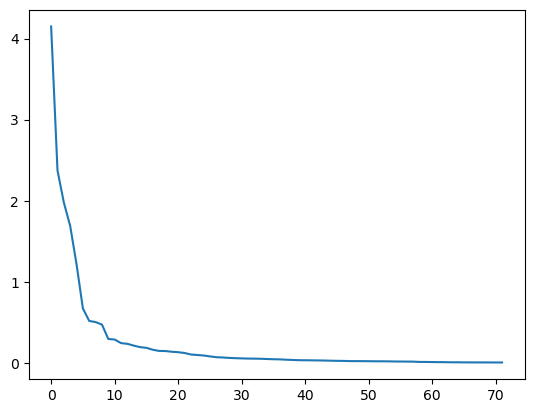

In [10]:
components = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/pca_components.csv',
                        index_col=0)

explained_variance = pd.read_csv('/Users/xies/Library/CloudStorage/OneDrive-Stanford/Skin/Mesa et al/Lineage models/Dataset pickles/pca_explained_variance.csv',
                                index_col=0)

plt.plot(explained_variance)
# The diagonal matrix
components

In [17]:
mean_shape

cyto_shcoeffs_L0M0C  Measurement shcoeff    17.295883
cyto_shcoeffs_L1M0C  Measurement shcoeff     0.263898
cyto_shcoeffs_L1M1C  Measurement shcoeff     0.046622
cyto_shcoeffs_L2M0C  Measurement shcoeff     3.459984
cyto_shcoeffs_L2M1C  Measurement shcoeff    -0.681392
                                              ...    
nuc_shcoeffs_L5M1S   Measurement shcoeff    -0.005408
nuc_shcoeffs_L5M2S   Measurement shcoeff     0.000032
nuc_shcoeffs_L5M3S   Measurement shcoeff    -0.002205
nuc_shcoeffs_L5M4S   Measurement shcoeff    -0.001859
nuc_shcoeffs_L5M5S   Measurement shcoeff     0.000777
Length: 72, dtype: float64

In [20]:
# from aicsshparam import shtools
from visualization import reconstruct_mesh_from_averaged_coeffs, reconstruct_mesh, plot_cells_side_by_side

k = 0
pc_name = f'PC{k}'
components.loc[pc_name]
## Get top/bottom by feature
nuc_cols = components.columns.str.startswith('nuc_')
cyto_cols = components.columns.str.startswith('cyto_')

max_theta = 10
min_theta = -10
reconstructed_pc_max = mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[pc_name] * max_theta
reconstructed_pc_min = mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[pc_name] * min_theta

pc0 = {'nuc':reconstruct_mesh(reconstructed_pc_max[nuc_cols])[0],
        'cyto':reconstruct_mesh(reconstructed_pc_max[cyto_cols])[0]}

pc0_min = {'nuc':reconstruct_mesh(reconstructed_pc_min[nuc_cols])[0],
        'cyto':reconstruct_mesh(reconstructed_pc_min[cyto_cols])[0]}

plot_cells_side_by_side([pc0,pc0_min])

Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x30a92bad0_1&reconnect=auto" class="pyvista…

In [35]:
basal_pcs = basals.swaplevel(axis=1)['Measurement shcoeff_PCA']
basal_pcs

shcoeff_PC0  shcoeff_PC1  shcoeff_PC2  shcoeff_PC3  \
Frame TrackID                                                       
0     R1_2        0.202088     2.123952     0.318756     1.531114   
      R1_5        1.982310     1.272519     0.766285     1.459471   
      R1_11      -1.557531     2.679790    -0.466025     0.785997   
      R1_19       1.673004    -0.596893     0.723491     1.236332   
      R1_24       1.795796     1.080700     2.771732     0.078998   
...                    ...          ...          ...          ...   
14    R2_1134     2.662344     0.061907    -1.036342     1.992887   
      R2_1144    -3.502526     1.285779     0.529730     0.732801   
      R2_1149    -0.837597    -0.507391     0.654213     0.345524   
      R2_1155    -1.052141    -0.978063    -0.117206     1.246708   
      R2_1156    -2.514656     0.771582    -1.674796    -0.498680   

               shcoeff_PC4  shcoeff_PC5  shcoeff_PC6  shcoeff_PC7  shcoeff_PC8  
Frame TrackID                                                                   
0     R1_2        0.354851     0.303716     0.063882    -0.429787     0.197767  
      R1_5        2.281965     0.244116     0.090856     0.071767     0.638267  
      R1_11       1.309727    -0.311803    -0.963018    -0.419976     0.334172  
      R1_19      -1.051404    -0.451066    -1.129211    -0.001809    -0.759999  
      R1_24       1.096085    -0.369195    -1.001146    -1.193320     0.905090  
...                    ...          ...          ...          ...          ...  
14    R2_1134     0.956304    -0.666575    -0.499256     0.405606     0.823546  
      R2_1144    -1.402707     0.666165    -0.023566     0.724067    -0.479817  
      R2_1149     0.349909     0.032640     0.078207    -1.256014     0.449811  
      R2_1155    -0.021381    -1.315705    -1.413661    -0.647066     1.235515  
      R2_1156    -0.623186     1.241359    -1.403110    -0.469105    -1.114647  

[8216 rows x 9 columns]

Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x36ac7c4a0_15&reconnect=auto" class="pyvist…

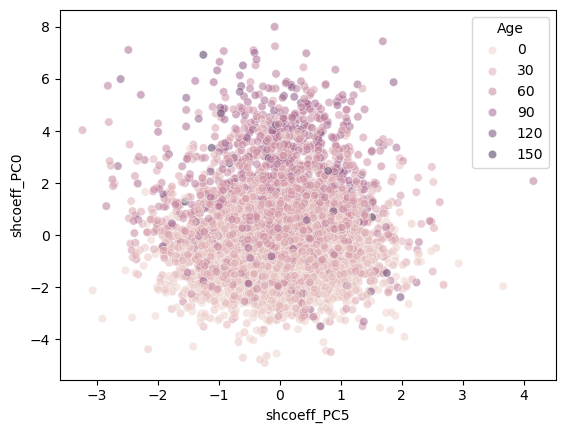

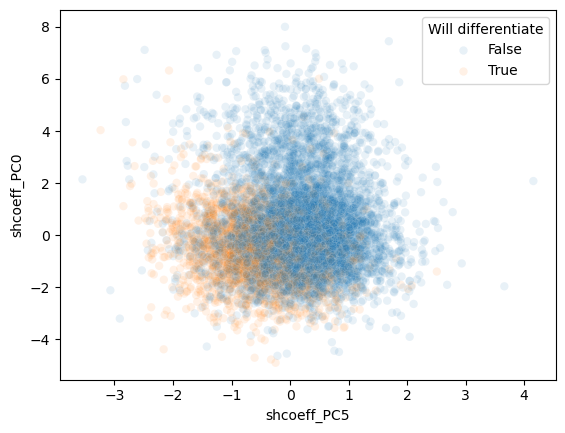

In [58]:
k = 0; k_name = f'PC{k}'
l = 5; l_name = f'PC{l}'

X = np.linspace(-10,10,8)
Y = np.linspace(-5,10,5)
pca_grid = {(x,y):
            mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[k_name] * x \
            + mean_shape + np.sqrt(explained_variance.loc[l]['Variance']) * components.loc[l_name] * y
             for x in Y for y in X}
mesh = []
for i,x in enumerate(Y):
    for j,y in enumerate(X):
        mesh.append({
            'nuc':reconstruct_mesh(pca_grid[x,y][nuc_cols])[0],
            'cyto':reconstruct_mesh(pca_grid[x,y][cyto_cols])[0]})

sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               # hue='Will differentiate',
               hue='Age',
               alpha=0.5)

plt.figure()
sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='Will differentiate',
               # hue='Age',
               alpha=0.1)
 
plot_cells_side_by_side(mesh,num_cols=8)


Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x3b22056a0_14&reconnect=auto" class="pyvist…

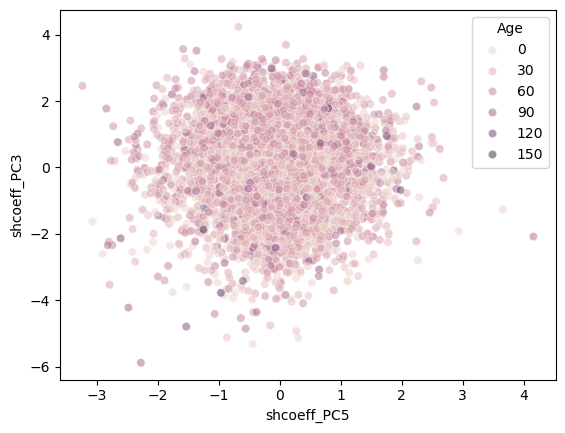

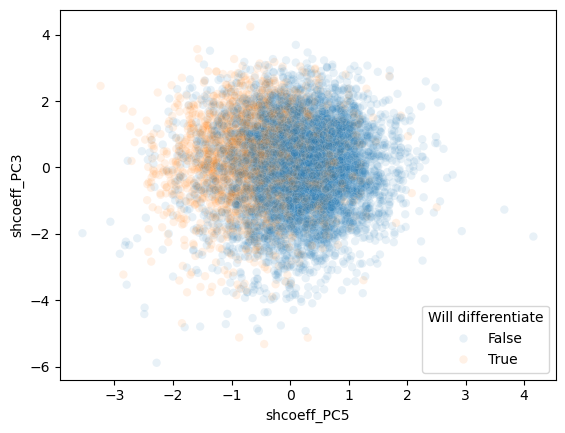

In [57]:
k = 3; k_name = f'PC{k}'
l = 5; l_name = f'PC{l}'

X = np.linspace(-10,10,8)
Y = np.linspace(-5,10,5)
pca_grid = {(x,y):
            mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[k_name] * x \
            + mean_shape + np.sqrt(explained_variance.loc[l]['Variance']) * components.loc[l_name] * y
             for x in Y for y in X}
mesh = []
for i,x in enumerate(Y):
    for j,y in enumerate(X):
        mesh.append({
            'nuc':reconstruct_mesh(pca_grid[x,y][nuc_cols])[0],
            'cyto':reconstruct_mesh(pca_grid[x,y][cyto_cols])[0]})

sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               # hue='Will differentiate',
               hue='Age',
               alpha=0.5)

plt.figure()
sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='Will differentiate',
               # hue='Age',
               alpha=0.1)
 
plot_cells_side_by_side(mesh,num_cols=8)


Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x15e200470_17&reconnect=auto" class="pyvist…

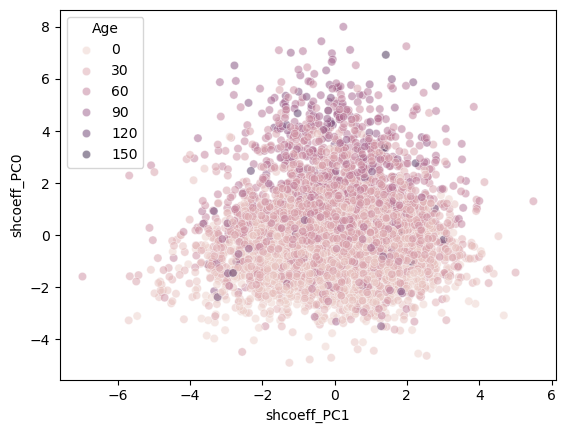

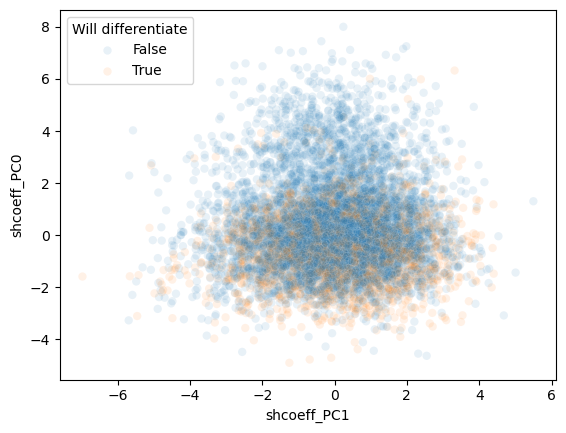

In [60]:
k = 0; k_name = f'PC{k}'
l = 1; l_name = f'PC{l}'

X = np.linspace(-10,10,8)
Y = np.linspace(-5,10,5)
pca_grid = {(x,y):
            mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[k_name] * x \
            + mean_shape + np.sqrt(explained_variance.loc[l]['Variance']) * components.loc[l_name] * y
             for x in Y for y in X}
mesh = []
for i,x in enumerate(Y):
    for j,y in enumerate(X):
        mesh.append({
            'nuc':reconstruct_mesh(pca_grid[x,y][nuc_cols])[0],
            'cyto':reconstruct_mesh(pca_grid[x,y][cyto_cols])[0]})

sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               # hue='Will differentiate',
               hue='Age',
               alpha=0.5)

plt.figure()
sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='Will differentiate',
               # hue='Age',
               alpha=0.1)

plot_cells_side_by_side(mesh,num_cols=8)


Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x45a331af0_46&reconnect=auto" class="pyvist…

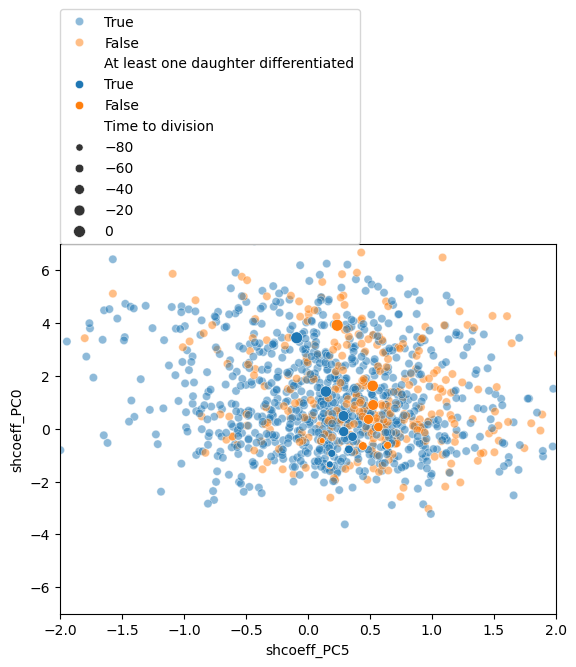

In [98]:
k = 0; k_name = f'PC{k}'
l = 5; l_name = f'PC{l}'

xlim = [-7,7]; ylim = [-2,2]

X = np.linspace(xlim[0],xlim[1],7)
Y = np.linspace(ylim[0],ylim[1],5)
pca_grid = {(x,y):
            mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[k_name] * x \
            + mean_shape + np.sqrt(explained_variance.loc[l]['Variance']) * components.loc[l_name] * y
             for x in Y for y in X}
mesh = []
for i,x in enumerate(Y):
    for j,y in enumerate(X):
        mesh.append({
            'nuc':reconstruct_mesh(pca_grid[x,y][nuc_cols])[0],
            'cyto':reconstruct_mesh(pca_grid[x,y][cyto_cols])[0]})

plt.figure()
sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='At least one daughter differentiated',hue_order=[True,False],
               alpha=0.5)
plt.xlim(ylim); plt.ylim(xlim)

g = sb.scatterplot(basals.droplevel(axis=1,level=1).groupby(
    ['Time to division','At least one daughter differentiated'])[[f'shcoeff_{l_name}',f'shcoeff_{k_name}']].mean().reset_index(),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='At least one daughter differentiated',hue_order=[True,False],
               size = 'Time to division',
               alpha=1)
plt.xlim(ylim); plt.ylim(xlim)
sb.move_legend(g,loc=[0,1])
 
plot_cells_side_by_side(mesh,num_cols=7)


Context leak detected, msgtracer returned -1


Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x424df1910_49&reconnect=auto" class="pyvist…

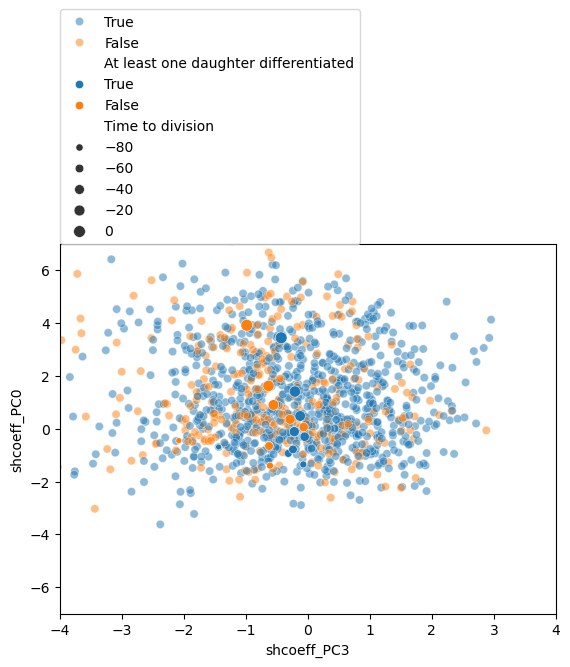

In [101]:
k = 0; k_name = f'PC{k}'
l = 3; l_name = f'PC{l}'

xlim = [-7,7]; ylim = [-4,4]

X = np.linspace(xlim[0],xlim[1],7)
Y = np.linspace(ylim[0],ylim[1],5)
pca_grid = {(x,y):
            mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[k_name] * x \
            + mean_shape + np.sqrt(explained_variance.loc[l]['Variance']) * components.loc[l_name] * y
             for x in Y for y in X}
mesh = []
for i,x in enumerate(Y):
    for j,y in enumerate(X):
        mesh.append({
            'nuc':reconstruct_mesh(pca_grid[x,y][nuc_cols])[0],
            'cyto':reconstruct_mesh(pca_grid[x,y][cyto_cols])[0]})

plt.figure()
sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='At least one daughter differentiated',hue_order=[True,False],
               alpha=0.5)
plt.xlim(ylim); plt.ylim(xlim)

g = sb.scatterplot(basals.droplevel(axis=1,level=1).groupby(
    ['Time to division','At least one daughter differentiated'])[[f'shcoeff_{l_name}',f'shcoeff_{k_name}']].mean().reset_index(),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='At least one daughter differentiated',hue_order=[True,False],
               size = 'Time to division',
               alpha=1)
plt.xlim(ylim); plt.ylim(xlim)
sb.move_legend(g,loc=[0,1])
 
plot_cells_side_by_side(mesh,num_cols=7)


Widget(value='<iframe src="http://localhost:64128/index.html?ui=P_0x4dd9409e0_51&reconnect=auto" class="pyvist…

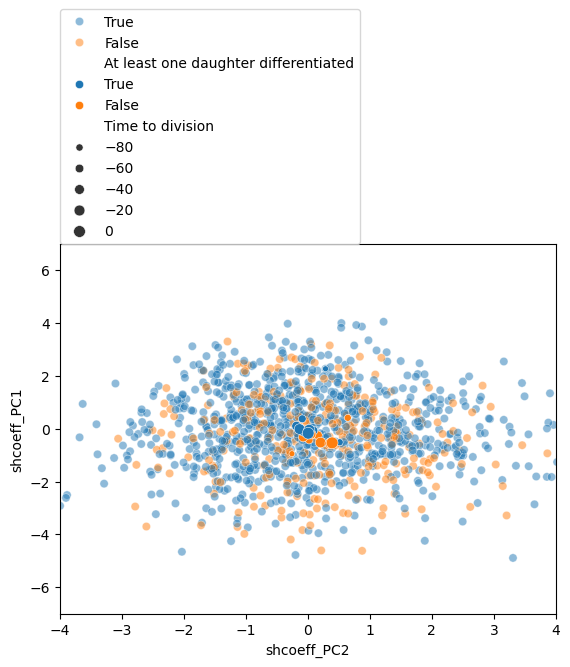

In [103]:
k = 1; k_name = f'PC{k}'
l = 2; l_name = f'PC{l}'

xlim = [-7,7]; ylim = [-4,4]

X = np.linspace(xlim[0],xlim[1],7)
Y = np.linspace(ylim[0],ylim[1],5)
pca_grid = {(x,y):
            mean_shape + np.sqrt(explained_variance.loc[k]['Variance']) * components.loc[k_name] * x \
            + mean_shape + np.sqrt(explained_variance.loc[l]['Variance']) * components.loc[l_name] * y
             for x in Y for y in X}
mesh = []
for i,x in enumerate(Y):
    for j,y in enumerate(X):
        mesh.append({
            'nuc':reconstruct_mesh(pca_grid[x,y][nuc_cols])[0],
            'cyto':reconstruct_mesh(pca_grid[x,y][cyto_cols])[0]})

plt.figure()
sb.scatterplot(basals.droplevel(axis=1,level=1),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='At least one daughter differentiated',hue_order=[True,False],
               alpha=0.5)
plt.xlim(ylim); plt.ylim(xlim)

g = sb.scatterplot(basals.droplevel(axis=1,level=1).groupby(
    ['Time to division','At least one daughter differentiated'])[[f'shcoeff_{l_name}',f'shcoeff_{k_name}']].mean().reset_index(),
               x=f'shcoeff_{l_name}',
               y = f'shcoeff_{k_name}',
               hue='At least one daughter differentiated',hue_order=[True,False],
               size = 'Time to division',
               alpha=1)
plt.xlim(ylim); plt.ylim(xlim)
sb.move_legend(g,loc=[0,1])
 
plot_cells_side_by_side(mesh,num_cols=7)
